# Basic utils for Investing based on Indicators

## Imports

In [1]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random
# import plotly.express as px


seed = 1

# Attribution d'une graine.
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Enable deterministic cuDNN behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
%reload_ext autoreload
%autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch_dtype = torch.float32

## Data reading and processing

In [2]:
pair = 'SOLUSDT'
timeframe = '5m'
type_data = 'Futures'

# Importation des données


data = pd.read_csv(f'../data/binance/{pair}_{timeframe}_{type_data}.csv', parse_dates=[0], index_col=0)
data

,Open,High,Low,Close,Volume,Qav,Trades,Taker_base_vol,Taker_quote_vol
Date,,,,,,,,,
2020-09-14 09:00:00,3.2002,4.9100,3.2002,3.3045,42698,1.426940e+05,640,15267,5.195271e+04
2020-09-14 09:05:00,3.3045,3.3974,3.2844,3.3497,51149,1.712361e+05,1152,28120,9.440854e+04
2020-09-14 09:10:00,3.3486,3.3576,3.3151,3.3393,23974,7.976511e+04,675,6843,2.276923e+04
2020-09-14 09:15:00,3.3443,3.4189,3.3353,3.3834,65640,2.223665e+05,1231,24917,8.447305e+04
2020-09-14 09:20:00,3.3855,3.4149,3.3709,3.3787,55165,1.865342e+05,825,11150,3.776340e+04
...,...,...,...,...,...,...,...,...,...
2024-09-04 19:35:00,133.0160,133.2070,132.5270,132.9030,173991,2.312146e+07,13635,64643,8.591545e+06
2024-09-04 19:40:00,132.9040,133.3170,132.7000,132.7360,72642,9.664593e+06,6799,36578,4.867733e+06
2024-09-04 19:45:00,132.7360,133.1360,132.7330,133.0310,43489,5.781083e+06,4668,24068,3.199412e+06


                         Open      High       Low     Close  Volume  \
Date                                                                  
2020-09-14 09:00:00    3.2002    4.9100    3.2002    3.3045   42698   
2020-09-14 09:05:00    3.3045    3.3974    3.2844    3.3497   51149   
2020-09-14 09:10:00    3.3486    3.3576    3.3151    3.3393   23974   
2020-09-14 09:15:00    3.3443    3.4189    3.3353    3.3834   65640   
2020-09-14 09:20:00    3.3855    3.4149    3.3709    3.3787   55165   
...                       ...       ...       ...       ...     ...   
2024-09-04 19:35:00  133.0160  133.2070  132.5270  132.9030  173991   
2024-09-04 19:40:00  132.9040  133.3170  132.7000  132.7360   72642   
2024-09-04 19:45:00  132.7360  133.1360  132.7330  133.0310   43489   
2024-09-04 19:50:00  133.0310  133.0680  132.5000  132.7810   55597   
2024-09-04 19:55:00  132.7790  132.7790  132.6720  132.6800    3284   

                              Qav  Trades  Taker_base_vol  Taker_quote_vol  

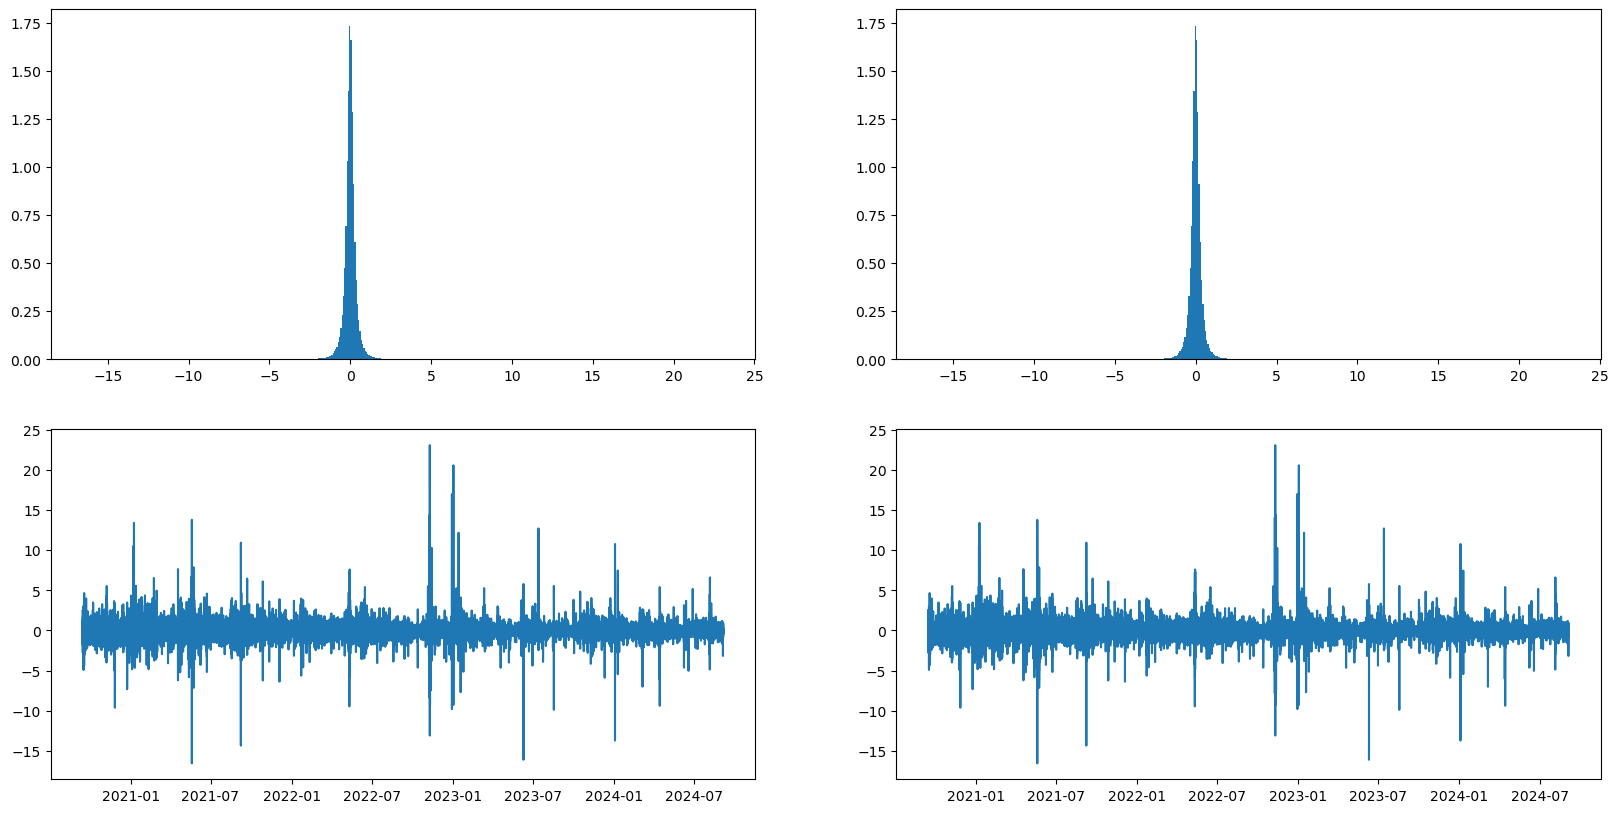

In [3]:
data.loc[:, '%R'] = data['Close'].pct_change()*100

print(data)

quatiles_threshold = 0.00001

plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)    
plt.hist(data['%R'] , bins=500, density=True)

plt.subplot(2, 2, 3)
plt.plot(data['%R'])

# data['%R'] = data['%R'].clip(lower=data['%R'].quantile(quatiles_threshold), upper=data['%R'].quantile(1-quatiles_threshold))

print(data['%R'].mean())

# data['%R'] = data['%R'] - data['%R'].mean()

plt.subplot(2, 2, 2)
plt.hist(data['%R'], bins=500, density=True)

plt.subplot(2, 2, 4)
plt.plot(data['%R'])

plt.show()

In [4]:
import ta

df = data[['%R']].copy()

# df['%R2'] = df['%R']**2 # no gain

# df['RSI_14'] = ta.momentum.rsi(df['%R'], window=14) # gain
# df['RSI_7'] = ta.momentum.rsi(df['%R'], window=7) # gain
# df['RSI_112'] = ta.momentum.rsi(df['%R'], window=112) # no gain
# df['RSI_21'] = ta.momentum.rsi(df['%R'], window=21) # gain
# df['RSI_28'] = ta.momentum.rsi(df['%R'], window=28) # gain
# df['RSI_35'] = ta.momentum.rsi(df['%R'], window=35) # no gain

df['RSI_14'] = ta.momentum.rsi(data['Close'], window=14) # gain
# df['RSI_7'] = ta.momentum.rsi(data['Close'], window=7) # gain
# df['RSI_112'] = ta.momentum.rsi(data['Close'], window=112) # gain


# df['MACD_12/26'] = ta.trend.macd(data['Close'], window_slow=26, window_fast=12) # gain



df.dropna(inplace=True)

In [5]:
df.describe()

,%R,RSI_14
count,418007.000000,418007.000000
mean,0.001821,50.089755
std,0.434454,11.254721
min,-16.548129,3.540648
25%,-0.165887,42.658427
50%,0.000000,50.026151
75%,0.166057,57.470163
max,23.072171,97.659776


In [6]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

train_data, test_data = df[:int(len(data)*0.8)], df[int(len(data)*0.8):]

train_data = train_data.to_numpy()

test_data = test_data.to_numpy()

start_index = 0

train_target = train_data[:, :1]

test_target = test_data[:, :1]

for k in range(0, 1):
    train_target = train_target - train_target.mean()
    test_target = test_target - test_target.mean()
    
    print(f'k = {k}: train_target mean = {train_target.mean()}, test_target mean = {test_target.mean()}')

scaler = StandardScaler()


train_data = scaler.fit_transform(train_data[:, start_index:]) 
test_data = scaler.transform(test_data[:, start_index:])

k = 0: train_target mean = 9.85873371467533e-18, test_target mean = 0.0


In [15]:
class ExpInvestLoss(nn.Module):
    def __init__(self, alpha=0.1):
        super(ExpInvestLoss, self).__init__()
        self.alpha = alpha

    def forward(self, y_pred, y_true):
        
        return torch.exp(-y_true*y_pred*self.alpha).mean()
    
class InvestLoss(nn.Module):
    def __init__(self, alpha=0):
        super(InvestLoss, self).__init__()
        self.alpha = alpha
    def forward(self, y_pred, y_true):
        
        r = y_true*y_pred
        
        return -r.mean()
    
class ADILoss(nn.Module):
    def __init__(self, fee=0.04):
        super(ADILoss, self).__init__()
        self.fee = fee
    def forward(self, inv, diff_inv, returns):
        
        if not self.fee == 0:
            return -((inv*returns).mean() - self.fee * diff_inv.abs().mean())

        else:
            return -(inv*returns).mean()
        
class PDILoss(nn.Module):
    def __init__(self, fee=0.04):
        super(PDILoss, self).__init__()
        self.fee = fee
    def forward(self, inv, diff_inv, returns, leverage=0.1, return_array=False):
        
        if not self.fee == 0:
            
            inv = inv.reshape(-1)
            
            gain = inv*returns - self.fee * diff_inv.abs()
            
            prod_gain = (1+gain/100*leverage).clamp(0)
            
            if return_array:
                return prod_gain
            
            return -prod_gain.prod()

        else:
            return -(1 + inv*returns/100).prod()**(1/len(inv)) - 1

In [26]:
split_factor = 32


train_src = torch.tensor(train_data[:-1], dtype=torch_dtype).to(device)
train_tgt = torch.tensor(train_target[1:], dtype=torch_dtype).to(device)

print(train_src.shape, train_tgt.shape, len(train_src)%split_factor)

train_src = train_src[len(train_src)%split_factor:].reshape(split_factor, -1, train_src.shape[1])
train_tgt = train_tgt[len(train_tgt)%split_factor:].reshape(split_factor, -1, train_tgt.shape[1])

test_src = torch.tensor(test_data[:-1], dtype=torch_dtype).to(device).unsqueeze(0)
test_tgt = torch.tensor(test_target[1:], dtype=torch_dtype).to(device).unsqueeze(0)

class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        
        self.h = 4
        
        self.rnn = nn.LSTM(train_src.shape[2], self.h, 2, batch_first=True)
        
        self.l1 = nn.Linear(self.h, self.h)
        self.l2 = nn.Linear(self.h, 1)
        
        self.gelu = nn.GELU()
        
        self.tanh = nn.Tanh()

    def forward(self, x):
        
        x, _ = self.rnn(x)
        
        x = self.gelu(self.l1(x))
        
        x = self.tanh(self.l2(x))

        
        return x-x.mean()
    
    
model = Model().to(device=device, dtype=torch_dtype)

pleverage = nn.Parameter(torch.tensor(-1, dtype=torch_dtype))

criterion = PDILoss(fee=0.04)

optimizer = torch.optim.Adam(model.parameters(), lr=2e-2, amsgrad=True, weight_decay=1e-7)

opt_leverage = torch.optim.Adam([pleverage], lr=1e-1, amsgrad=True)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4000, gamma=0.9)

train_loss = []
test_loss = []

def run_model(model, src, tgt, return_array=False, leverage=0.1):
    
    inv = model(src).reshape(-1)
    tgt = tgt.reshape(-1)
    diff_inv = torch.cat([torch.tensor([0.], device=device), inv]).diff()
    
    loss = criterion(inv, diff_inv, tgt.squeeze(), return_array=return_array, leverage=leverage)
    
    return loss


num_epochs = 30

for epoch in tqdm(range(num_epochs)):
    
    leverage = pleverage.sigmoid()
    

    model.eval()
        
    test_loss.append((-run_model(model, test_src, test_tgt, leverage=leverage).detach().item())**(1/len(train_src)))
    
    model.train()
    optimizer.zero_grad()
    opt_leverage.zero_grad()

    loss = run_model(model, train_src, train_tgt, leverage=leverage)
    loss.backward()
    

    optimizer.step()
    scheduler.step()
    
    train_loss.append((-loss.detach().item())**(1/len(train_src)))
    opt_leverage.step()
    

    
    if epoch % (1) == 0:

        print(f'Epoch {epoch}: train loss {train_loss[-1]-1:.3E}, test loss {test_loss[-1]-1:.3E}, leverage {leverage.item():.3E}')



torch.Size([334415, 2]) torch.Size([334415, 1]) 15


  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 0: train loss -1.398E-03, test loss -4.361E-04, leverage 2.689E-01
Epoch 1: train loss -4.192E-04, test loss -2.099E-04, leverage 2.497E-01
Epoch 2: train loss -3.772E-04, test loss -1.651E-04, leverage 2.342E-01
Epoch 3: train loss -2.887E-04, test loss -1.214E-04, leverage 2.205E-01
Epoch 4: train loss -1.376E-04, test loss -7.494E-05, leverage 2.082E-01
Epoch 5: train loss -3.724E-05, test loss -4.238E-05, leverage 1.978E-01
Epoch 6: train loss -2.985E-05, test loss -3.698E-05, leverage 1.894E-01
Epoch 7: train loss -5.073E-05, test loss -3.967E-05, leverage 1.826E-01
Epoch 8: train loss -4.342E-05, test loss -3.742E-05, leverage 1.769E-01
Epoch 9: train loss -1.464E-05, test loss -3.239E-05, leverage 1.721E-01
Epoch 10: train loss 1.784E-05, test loss -2.620E-05, leverage 1.683E-01
Epoch 11: train loss 4.787E-05, test loss -2.132E-05, leverage 1.654E-01
Epoch 12: train loss 7.138E-05, test loss -1.920E-05, leverage 1.636E-01
Epoch 13: train loss 1.003E-04, test loss -1.833E-0

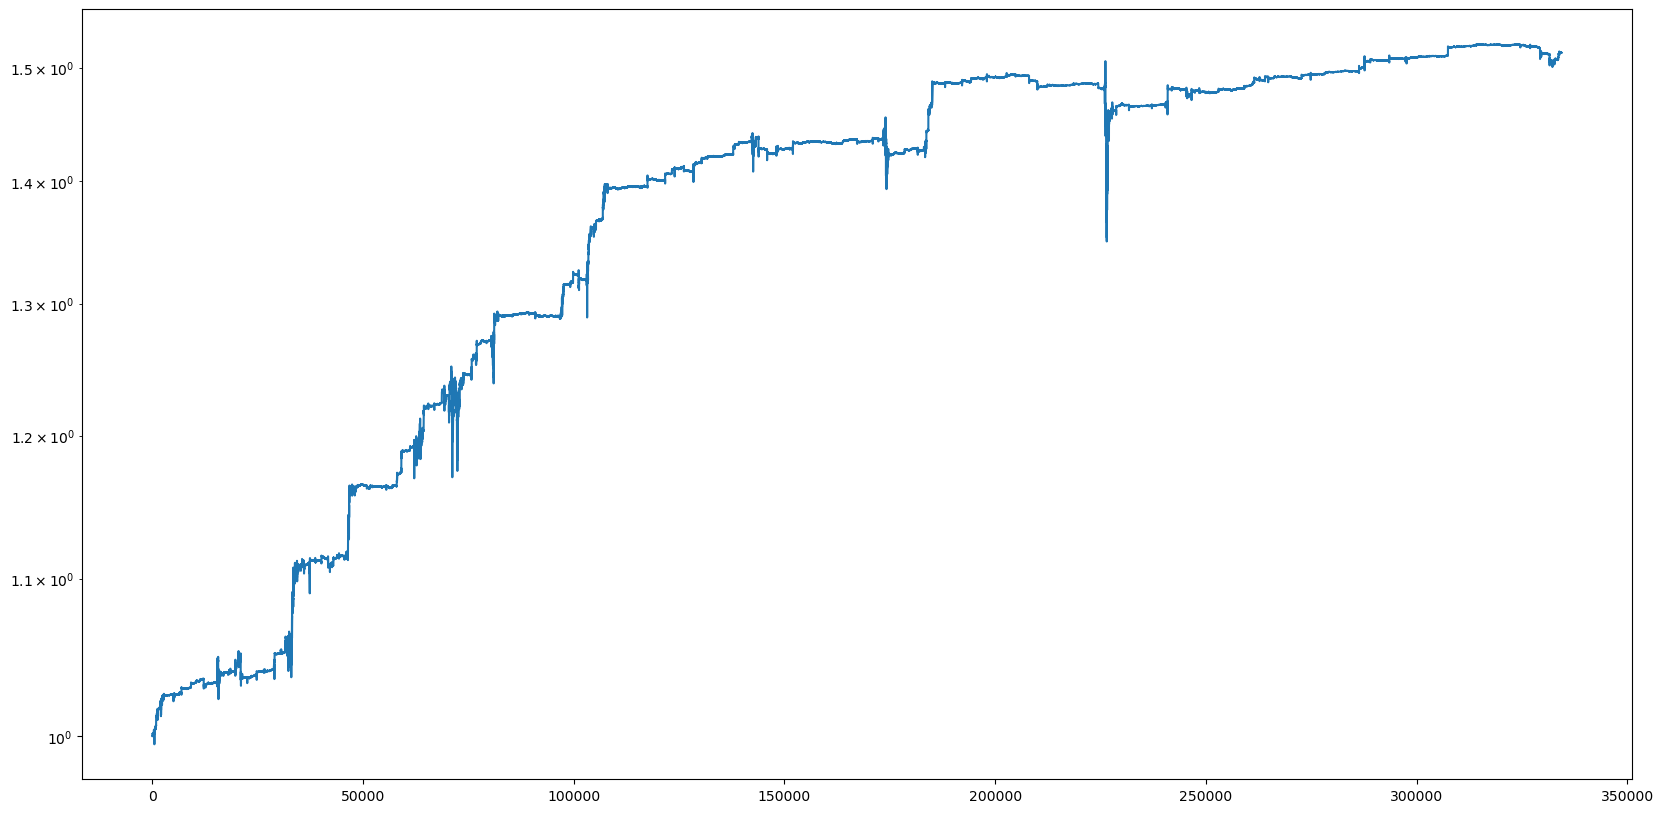

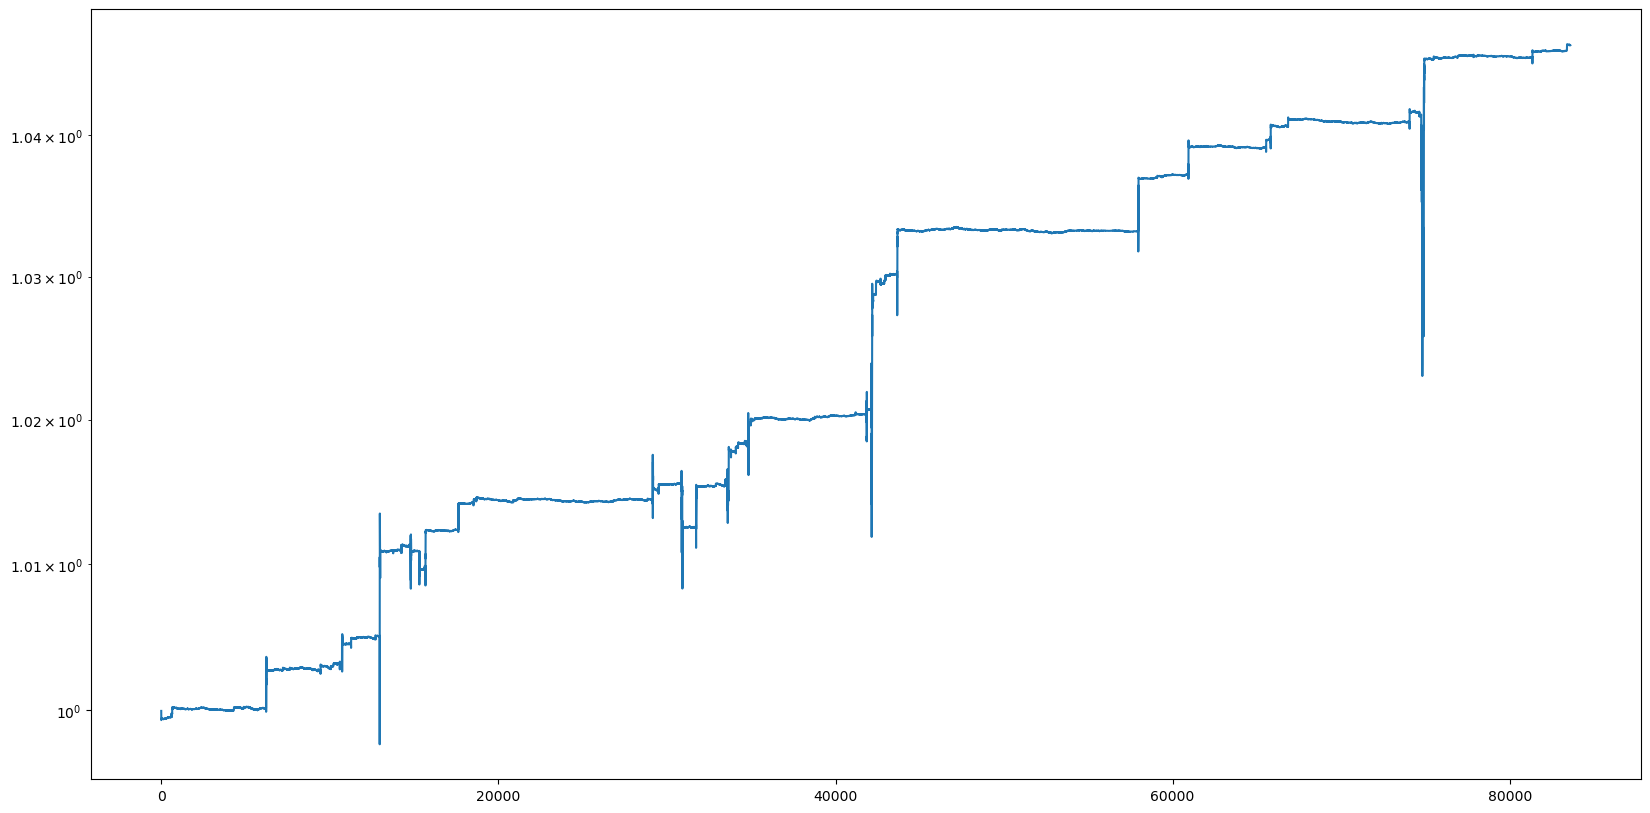

In [27]:

train_gain = run_model(model, train_src, train_tgt, return_array=True, leverage=leverage.item())
test_gain = run_model(model, test_src, test_tgt, return_array=True, leverage=leverage.item())

train_gain = run_model(model, train_src, train_tgt, return_array=True, leverage=0.1)
test_gain = run_model(model, test_src, test_tgt, return_array=True, leverage=0.1)

plt.figure(figsize=(20, 10))
plt.plot(train_gain.cpu().detach().numpy().cumprod(), label='train')
plt.yscale('log')
plt.show()

plt.figure(figsize=(20, 10))
plt.plot(test_gain.cpu().detach().numpy().cumprod(), label='test')
plt.yscale('log')
plt.show()
